In this notebook we'll analyze the **North Carolina Voter Registration (NCVR)** dataset and propose a solution for record linkage in this dataset.

Here's a description of the dataset:

The North Carolina Voters dataset is based on real person records from the North-Carolina voter registry and synthetically generated duplicates using the tool GeCo. We consider two configurations with either 5 or 10 sources (here 5) each having 1 million entities; i.e. we process up to 10 million person records. Each source is duplicate free, but 50% of the entities are replicated in all sources without any corruption. Moreover, 25% of entities are corrupted and replicated in all sources, and the remaining 25% are corrupted but present in only some sources. For the generation of corrupted records we applied a moderate corruption rate of 20%, i.e., most attribute values remained unchanged.

This is the model we'll fine-tune: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initial EDA

In [2]:
df1 = pd.read_csv('../data/north_carolina_voters/dataset_1.csv')
df2 = pd.read_csv('../data/north_carolina_voters/dataset_2.csv')
df3 = pd.read_csv('../data/north_carolina_voters/dataset_3.csv')
df4 = pd.read_csv('../data/north_carolina_voters/dataset_4.csv')
df5 = pd.read_csv('../data/north_carolina_voters/dataset_5.csv')

df = df1

/tmp/ipykernel_10170/2176530505.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../data/north_carolina_voters/dataset_1.csv')
/tmp/ipykernel_10170/2176530505.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../data/north_carolina_voters/dataset_2.csv')
/tmp/ipykernel_10170/2176530505.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('../data/north_carolina_voters/dataset_3.csv')
/tmp/ipykernel_10170/2176530505.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv('../data/north_carolina_voters/dataset_4.csv')
/tmp/ipykernel_10170/2176530505.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv('../data/north_carolin

In [3]:
df_concat = pd.concat([df1, df2, df3, df4, df5])
df_concat.shape

(5000000, 5)

In [5]:
df_concat['recid'].nunique()

3500840

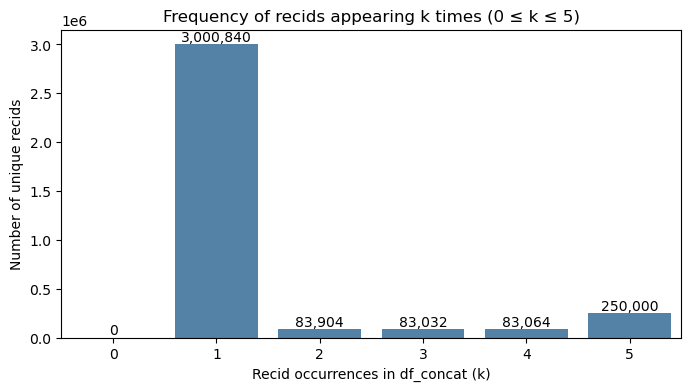

,num_recids
k occurrences,
0,0
1,3000840
2,83904
3,83032
4,83064
5,250000


In [6]:
recid_counts = df_concat['recid'].value_counts()

binned_counts = (
    recid_counts.clip(upper=5)  # treat 5 as "5 or more"
    .value_counts()
    .reindex(range(0, 6), fill_value=0)
    .sort_index()
)

plt.figure(figsize=(8, 4))
bars = sns.barplot(x=binned_counts.index, y=binned_counts.values, color="steelblue")
plt.xlabel("Recid occurrences in df_concat (k)")
plt.ylabel("Number of unique recids")
plt.title("Frequency of recids appearing k times (0 ≤ k ≤ 5)")

for bar, count in zip(bars.patches, binned_counts.values):
    bars.annotate(f"{int(count):,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha="center", va="bottom", fontsize=10)

plt.show()

binned_counts.rename_axis("k occurrences").to_frame("num_recids")

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df['surname'].value_counts()[:1000]

In [ ]:
suburbs = df['suburb'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=suburbs.values, 
    y=suburbs.index)

plt.show()

In [ ]:
surnames = df['surname'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=surnames.values, 
    y=surnames.index)

plt.show()

In [ ]:
givennames = df['givenname'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=givennames.values, 
    y=givennames.index)

plt.show()

In [ ]:
df['postcode'].value_counts()[:10]

In [ ]:
postcodes = df['postcode'].value_counts()[:10]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=postcodes.values, 
    y=postcodes.index)

plt.show()

# Basic pandas operations

In [ ]:
# Employees DataFrame
employees_data = {
    'emp_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'first_name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi'],
    'salary': [70000, 85000, 60000, 95000, 110000, 55000, np.nan, 72000],
    'dept_id': [1, 2, 1, 2, 3, 3, 1, 4]
}
employees = pd.DataFrame(employees_data)

# Departments DataFrame
departments_data = {
    'dept_id': [1, 2, 3, 5],
    'dept_name': ['Engineering', 'Sales', 'Marketing', 'HR']
}
departments = pd.DataFrame(departments_data)

In [ ]:
employees[['emp_id', 'salary']].rename(columns={'emp_id': 'id'}).head(3)

In [ ]:
employees.query(
    'salary.between(60000, 90000) and dept_id.isin([1, 3])'
)[['first_name', 'dept_id']]

In [ ]:
result = (
    employees
    .dropna(subset='salary')
    .groupby('dept_id')
    .agg(
        num_employees=('emp_id', 'count'),
        avg_salary=('salary', 'mean')
    )
    .rename_axis('dept_id')
    .reset_index()
    .query('num_employees > 1')
    .sort_values('avg_salary', ascending=False)
)
print(result)

In [ ]:
result = pd.merge(
    employees,
    departments,
    on='dept_id',
    how='left'
)

result = result[['first_name', 'salary', 'dept_name']]

print(result)

In [ ]:
from sys import api_version


merged_df = pd.merge(employees, departments, on='dept_id', how='inner')

final_result = (
    merged_df
    .query("first_name < 'F' and salary.notna()")
    .groupby("dept_name")
    .agg(
        employee_count=('emp_id', 'count'),
        average_salary=('salary', lambda s : round(s.mean(), 0))
    )
    .query("employee_count >= 2")
    .sort_values('average_salary', ascending=False)
    .head(1)
)

print(final_result)